#correlation
correlation measures how strongly two variables move together

Range -1<=r<=1

value            meaning
1                perfect positive relationship
0                no relationship
-1               perfect negative relationship

In [10]:
import pandas as pd
data={
    "Hours studied":[1,2,3,4,5,6,7,8,9,10],
    "Exam score":[40,45,50,55,60,65,70,75,80,85],
    "Rank":[10,9,8,7,6,5,4,3,2,1]
}
df=pd.DataFrame(data)
df

,Hours studied,Exam score,Rank
0,1,40,10
1,2,45,9
2,3,50,8
3,4,55,7
4,5,60,6
5,6,65,5
6,7,70,4
7,8,75,3
8,9,80,2
9,10,85,1


In [11]:
#pearson correlation - measures linea relationship
print(df["Hours studied"].corr(df["Exam score"]))
# very strong positive linear relationship
#meaning study hours -> exam score (higher study hours = higher exam score)

1.0


#spearmen correlation - measures rank relationship instead of actual values

useful when:
1. data is monotonic but not linear
2. rankings are used
3. ordinal variables

In [12]:
df.corr(method='spearman')

,Hours studied,Exam score,Rank
Hours studied,1.0,1.0,-1.0
Exam score,1.0,1.0,-1.0
Rank,-1.0,-1.0,1.0


the output above is called a correlation matrix

rows and columns represent variables
each cell represents spearman correlation between those two variables

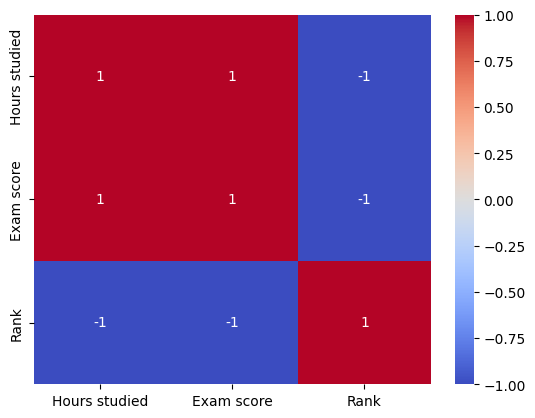

In [ ]:
#visualising correlation

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()
#red = positive realtionship
#blue = negative relationship
#near white = weak relationship

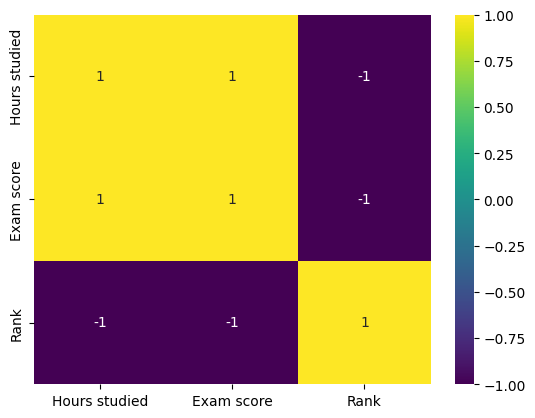

In [14]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(),annot=True,cmap="viridis")
plt.show()

In [16]:
df=pd.DataFrame({
    "Sales":[200,220,250,270,300],
    "Advertising":[50,60,70,80,90],
    "Price":[10,9,8,7,6],
    "Website_visits":[1000,1200,1400,1600,1800]
})
df.corr()

,Sales,Advertising,Price,Website_visits
Sales,1.000000,0.997609,-0.997609,0.997609
Advertising,0.997609,1.000000,-1.000000,1.000000
Price,-0.997609,-1.000000,1.000000,-1.000000
Website_visits,0.997609,1.000000,-1.000000,1.000000


#Advertising strongly increases sales
#price negatively impacts sales
#visits correlate with sales


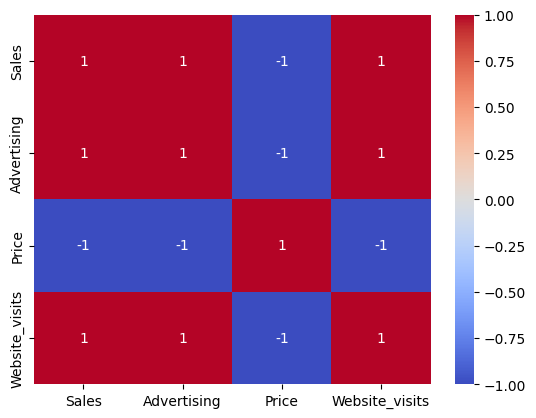

In [21]:
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

#outliers affect correlation

example:

hours           sleep
-----            ------
2                 40
3                 45
4                 50
5                 55
10                30

the last value here is an outlier
this can drastically reduce pearson correlation but spearman would be more stable

example dataset:  (pearson correlation)

student       hours studied     Exam score
A                 2                 40
B                 4                 50
C                 6                 60  
D                 8                 70

student       hours Rank        Exam Rank
A                 1                 1
B                 2                 2
C                 3                 3  
D                 4                 4
(#spearman correlation)

#correlation is not always equal to causation

Ice cream sales                    drowining sales
Increasing                         Increasing

Actual case:
Hot weather or temperature

#this is called confounding variable
(confounding variable means variable the confuses the relationship between other variable)

In [ ]:
#distribution shapes
#a distribution describes how values are spread

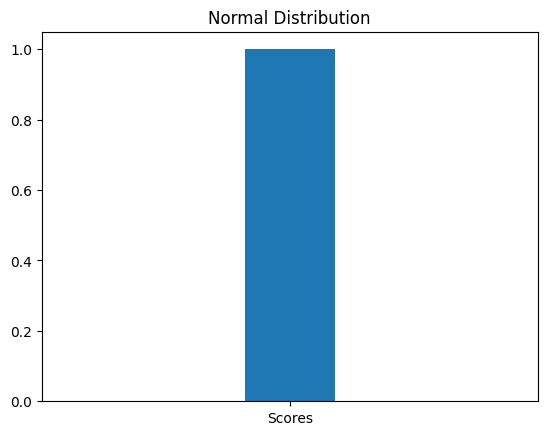

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
Scores=[40,42,44,46,48,50,52,54,56,58,60]
df=pd.DataFrame(Scores)

plt.hist("Scores",bins=5)
plt.title("Normal Distribution")
plt.show()

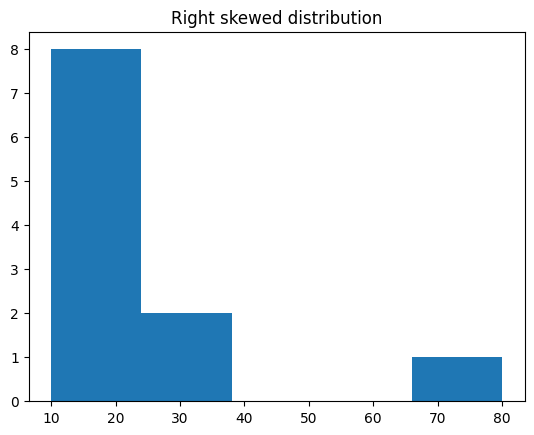

In [ ]:
right_skew=[10,12,14,15,16,18,20,22,25,30,80]
df=pd.DataFrame({"Income":right_skew})
plt.hist(df["Income"],bins=5)
plt.title("Right skewed distribution")
plt.show()

#very few large values pull the mean upward
#mean>median

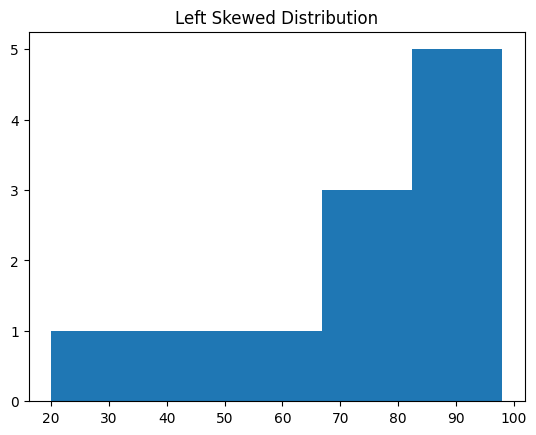

In [ ]:
left_skew = [20,50,60,70,75,80,85,90,92,95,98]

df = pd.DataFrame({"Exam_Scores":left_skew})

plt.hist(df["Exam_Scores"], bins=5)
plt.title("Left Skewed Distribution")
plt.show()
#Tail extends to the left 
#mean<median

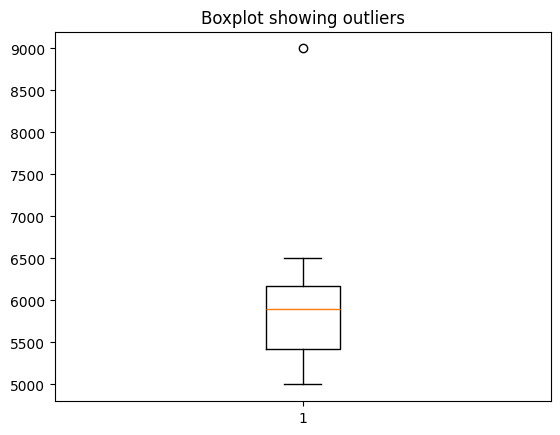

In [2]:
#kurtosis/Heavy tails
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
Sales = [5000,5200,5400,5500,5800,6000,6100,6200,6500,9000]

df = pd.DataFrame({"Sales":Sales})

plt.boxplot(df["Sales"])
plt.title("Boxplot showing outliers")
plt.show()


Kurtosis (tail heaviness)
Kurtosis measures how extreme the tails of a distribution are 

high kurtosis - more extreme values
low kurtosis - fever extreme values

In [ ]:
print(df["Sales"].kurt())
# >0 heavy tails
# <0 low tails
# ~normal distribution

5.738842872518954


Hypothesis-

A hypothesis is a testable statement about a population or relationship between variabkes

in data analytics , we test whether a difference we observe in data is real or just due to random variation 

example:
Did a new marketing campaign increase sales
we use hypothesis testing to answer this

two types of hypothesis:
1. Null hypothesis
2. Alternative hypothesis


a teacher wants to improve her teaching method and wants to verify if the new method is helping students score

for this she collects old scores, before and after changing her teaching method

old scores:                    new scores:
70                              78
72                              80
68                              76
71                              79
69                              77

observation: scores using the new method appear higher

but we need to check whether the improvement is real or could it happen randomly?

steps:
step 1:
Null hypothesis - the teaching method makes no difference

H0 : mean score (old method) = mean score (new method)

Alternative method : the new teaching method improves the score

H1 : mean score (new method) > mean score (old method) 

Step 2:
check the averages 
old method average = 70
new method average = 78

Average improvement = 8 marks
but we need to check if the difference is stasistically meaningful

step 3 :
performing a t-test
we use a t-test to compare two groups

In [5]:
from scipy.stats import ttest_ind
old=[70,72,68,71,69]
new=[78,80,76,79,77]
stat,p=ttest_ind(old,new)
print("{:.6f}".format(p))

0.000044


step 4:
interpret the p-value
decision rule:
condition                 decision
------------              ------------ 
p<0.05                     Reject H0
p>0.05                     do not rejrct H0

here p=0.000044 < 0.05
conclusion:
the improvement is statistically significant . the new teaching method likely improves student scores 
If the teaching actually made no difference , the chance of observing a difference this large is 0.1%
 so the improvement is very unlikely to be random
 

Null hypothesis - assumes no difference

alternative hypothesis - assumes there is a difference

p-value - probability that the result happened by chance

small p-value - strong evidence of real effect